<a href="https://colab.research.google.com/github/2118024/forecasting-rupiah-indonesia2045/blob/main/Membedah_%22Indonesia_Emas_vs_Cemas%22_Lewat_Proyeksi_Nilai_Tukar_Rupiah_(USD_IDR)_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import yfinance as yf
import pandas_datareader.data as web
import datetime
start ="2016-01-01"
end = datetime.datetime.now().strftime('%Y-%m-%d')
df_kurs = yf.download("IDR=X", start=start, end=end)[["Close"]]
df_dxy = web.DataReader ('DTWEXBGS','fred',start,end)

print("data berhasil diintegrasikan ke DataFrame!")

/tmp/ipykernel_1762/813516925.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_kurs = yf.download("IDR=X", start=start, end=end)[["Close"]]
[*********************100%***********************]  1 of 1 completed

data berhasil diintegrasikan ke DataFrame!


/tmp/ipykernel_1762/2556499203.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  nilai_terakhir = float(df_kurs['Close'].values[-1])


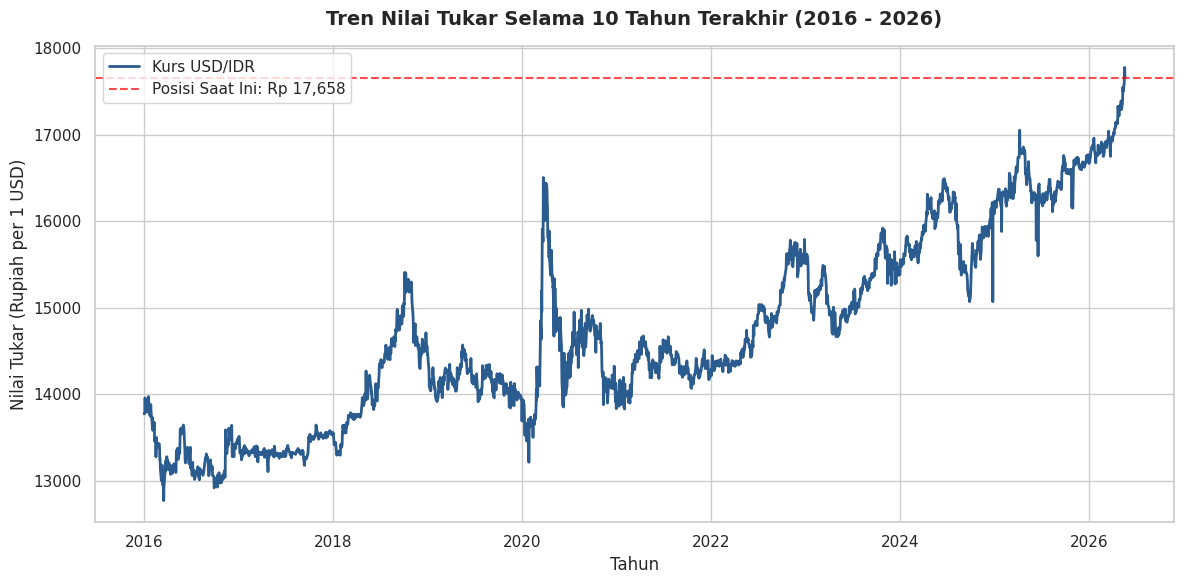

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

nilai_terakhir = float(df_kurs['Close'].values[-1])


plt.plot(df_kurs.index, df_kurs['Close'], color='#2b5c8f', linewidth=2, label='Kurs USD/IDR')

plt.title('Tren Nilai Tukar Selama 10 Tahun Terakhir (2016 - 2026)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Nilai Tukar (Rupiah per 1 USD)', fontsize=12)

plt.axhline(nilai_terakhir, color='red', linestyle='--', alpha=0.7,
            label=f"Posisi Saat Ini: Rp {nilai_terakhir:,.0f}")

# Memperbaiki typo plt.lengend -> plt.legend
plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
# 1. Pastikan library Prophet sudah terinstal
!pip install prophet

from prophet import Prophet
import pandas as pd

# 2. Menyiapkan data sesuai format wajib Prophet
# Prophet membutuhkan kolom bernama 'ds' (untuk tanggal) dan 'y' (untuk nilai angka)
df_prophet = df_kurs[['Close']].reset_index()
df_prophet.columns = ['ds', 'y']

# Memastikan tipe data bersih
df_prophet['ds'] = pd.to_datetime(df_prophet['ds'])
df_prophet['y'] = pd.to_numeric(df_prophet['y'], errors='coerce')
df_prophet = df_prophet.dropna()

# 3. Inisialisasi Model
# Kita aktifkan tren musiman tahunan (yearly_seasonality) untuk melihat pola berulang setiap tahun
model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
model.fit(df_prophet)

# 4. Membuat target lini masa prediksi (365 hari ke depan)
future = model.make_future_dataframe(periods=365)
forecast = model.predict(future)

print("Proses training model selesai! Siap menampilkan hasil prediksi.")

Proses training model selesai! Siap menampilkan hasil prediksi.


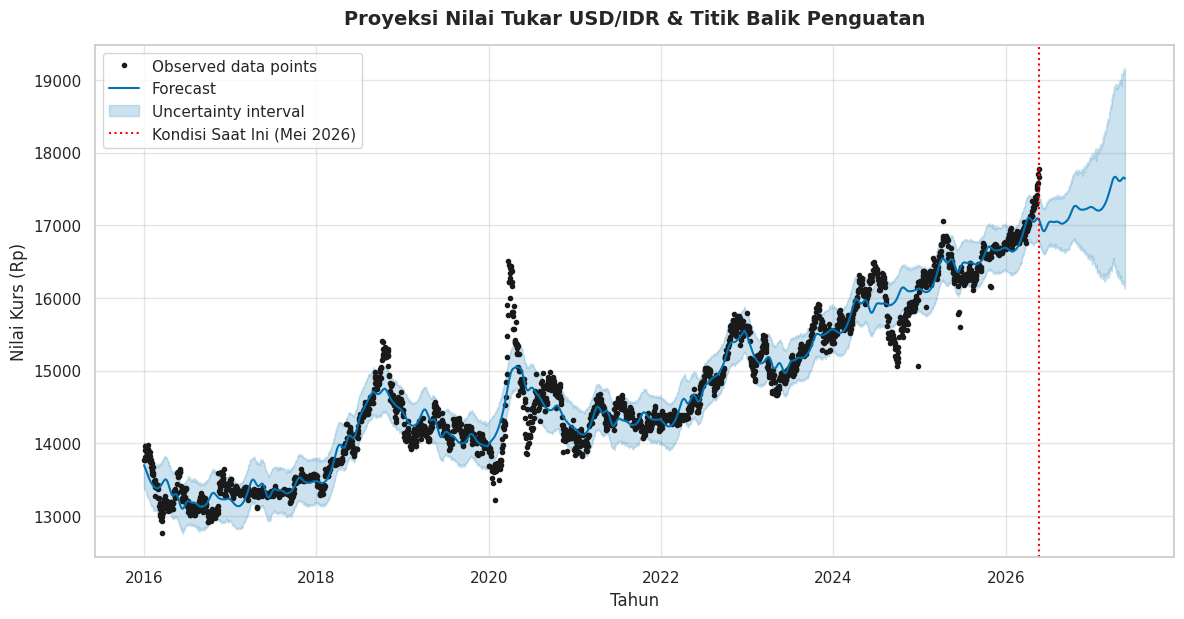

In [ ]:
import matplotlib.pyplot as plt

# Plot grafik hasil prediksi utama
fig1 = model.plot(forecast, figsize=(12, 6))

# Kustomisasi visual agar lebih mudah dibaca
plt.title('Proyeksi Nilai Tukar USD/IDR & Titik Balik Penguatan', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Nilai Kurs (Rp)', fontsize=12)
plt.axvline(pd.to_datetime('2026-05-22'), color='red', linestyle=':', label='Kondisi Saat Ini (Mei 2026)')
plt.legend(loc='upper left')
plt.show()

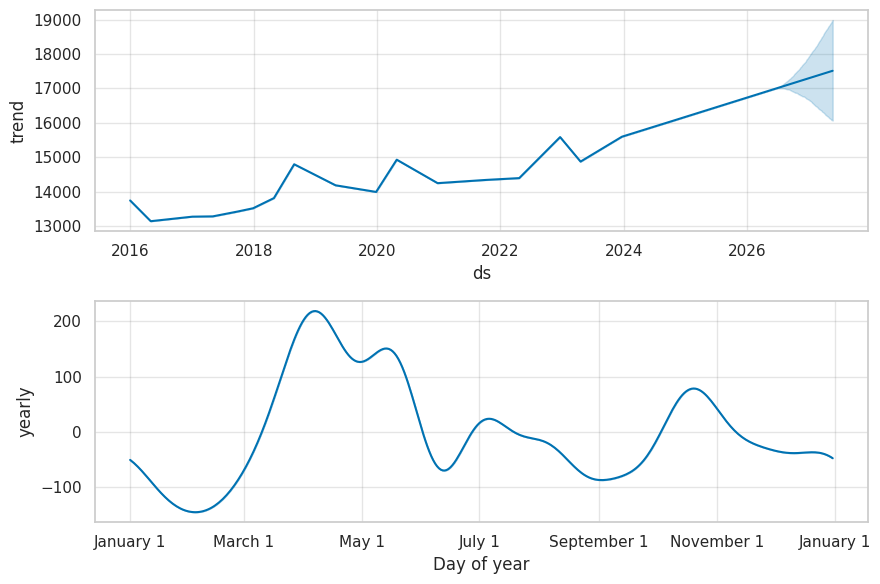

In [ ]:
# Menampilkan komponen pemisah: Tren Makro vs Pola Musiman Tahunan
fig2 = model.plot_components(forecast)
plt.show()

In [ ]:
import pandas_datareader.data as web
import datetime

# 1. Mengambil data Indeks Dolar (DXY) dan Suku Bunga Efektif AS dari FRED
start_date = "2016-01-01"
end_date = datetime.datetime.now().strftime('%Y-%m-%d')

df_macro = web.DataReader(['DTWEXBGS', 'FEDFUNDS'], 'fred', start_date, end_date)
df_macro.columns = ['Indeks_Dolar_DXY', 'Suku_Bunga_Fed_Rate']

# 2. Solusi MergeError: Meratakan kolom MultiIndex dari df_kurs
df_kurs_clean = df_kurs.copy()
if isinstance(df_kurs_clean.columns, pd.MultiIndex):
    # Mengambil level pertama saja (misal hanya mengambil 'Close')
    df_kurs_clean.columns = df_kurs_clean.columns.get_level_values(0)

# Mengubah nama kolom Close menjadi lebih spesifik
df_kurs_clean.columns = ['Kurs_USD_IDR']

# 3. Menyelaraskan tanggal menggunakan inner join yang aman
df_combined = df_kurs_clean.join(df_macro, how='inner').ffill()

print("Data makro berhasil digabungkan tanpa error!")
print(df_combined.tail())

Data makro berhasil digabungkan tanpa error!
            Kurs_USD_IDR  Indeks_Dolar_DXY  Suku_Bunga_Fed_Rate
2026-05-11  17358.000000          118.0562                 3.64
2026-05-12  17413.000000          118.5238                 3.64
2026-05-13  17549.000000          118.4737                 3.64
2026-05-14  17500.000000          118.6696                 3.64
2026-05-15  17530.599609          119.2825                 3.64


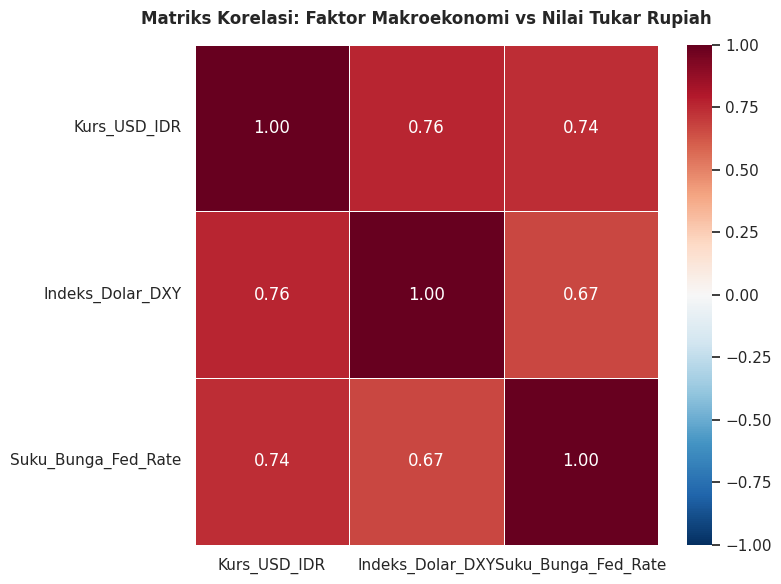

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Menghitung matriks korelasi Pearson
correlation_matrix = df_combined.corr()

# Plot Heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)

plt.title('Matriks Korelasi: Faktor Makroekonomi vs Nilai Tukar Rupiah', fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()